In [1]:
import sys
sys.path.insert(1, '/home/fainx/MyPythonLibrary/MAR-RECAP/libmar/')
import climbasis as climb
from climbasis import *
import domain as dom
import myplot
import numpy.ma as ma
from myplot import *
import obsinfo as obs
from obsinfo import *
from datetime import datetime
import mar
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [2]:
iyr=1980;fyr=2024
domain='GRf'
domain_2 = 'GRp'
domain_3 = 'GRp_bug'

latS,latN,lonW,lonE,latlim,lonlim=dom.coord_domain(domain)  
print(latS,latN,lonW,lonE)

# Removed pixels on domain boundaries
k =10

36 41 67 78


In [3]:
# Fedchenko area
#lon
w=24 ; x=34
#lat
y=40 ; z=52

In [4]:
# Ice thresold, 2025_28_11_Grp*.nc
ice_threshold = 40

In [5]:
# Jasgulem ice core coordinates:
jasg_lat = 38.54063
jasg_lon = 72.269816

In [6]:
sourceData_1='/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/' + domain_3 +'/spin2/work/monthly/'
sourceData_2='/bettik/PROJECTS/pr-regional-climate/fainx/'
folder_figure = '/bettik/PROJECTS/pr-regional-climate/fainx/figures/' + domain_2 +'/'

In [7]:
season_list = ["DJF", "MAM", "JJA", "SON"]

In [8]:
# MAR topography
sourceDataGrid='/home/amoryc/'
fileName_grF='NST.2000.01.01.00.GRp.nc'
ds_grF= xr.open_dataset(sourceDataGrid+fileName_grF)

# Enlever k pixels sur les contours
ds_lon=ds_grF.LON[k:-k,k:-k]
ds_lat=ds_grF.LAT[k:-k,k:-k]
ds_SH=ds_grF.SH[k:-k,k:-k]
ds_ICE=ds_grF.ICE[k:-k,k:-k]

ds_lon = ds_lon.rename({"y": "Y", "x": "X"})
ds_lat = ds_lat.rename({"y": "Y", "x": "X"})
ds_SH = ds_SH.rename({"y": "Y", "x": "X"})
ds_ICE = ds_ICE.rename({"y": "Y", "x": "X"})

ds_lon = ds_lon.assign_coords(X=np.round(ds_lon.X.values))
ds_lon = ds_lon.assign_coords(Y=np.round(ds_lon.Y.values))

ds_lat = ds_lat.assign_coords(X=np.round(ds_lat.X.values))
ds_lat = ds_lat.assign_coords(Y=np.round(ds_lat.Y.values))

ds_SH = ds_SH.assign_coords(X=np.round(ds_SH.X.values))
ds_SH = ds_SH.assign_coords(Y=np.round(ds_SH.Y.values))

ds_ICE = ds_ICE.assign_coords(X=np.round(ds_ICE.X.values))
ds_ICE = ds_ICE.assign_coords(Y=np.round(ds_ICE.Y.values))

In [9]:
# Identifier les indices X et Y correspondant au point de grille ou se trouve la carotte Jasgulem

# distance sur grille
dist = np.sqrt((ds_lat - jasg_lat)**2 + (ds_lon - jasg_lon)**2)

# index 1D du minimum
idx_1d = dist.argmin().item()

# conversion en indices 2D (Y, X)
iY, iX = np.unravel_index(idx_1d, dist.shape)

print("Indice Y :", iY)
print("Indice X :", iX)
print("Latitude trouvée :", ds_lat[iY, iX].item())
print("Longitude trouvée :", ds_lon[iY, iX].item())

Indice Y : 26
Indice X : 47
Latitude trouvée : 38.54820251464844
Longitude trouvée : 72.30000305175781


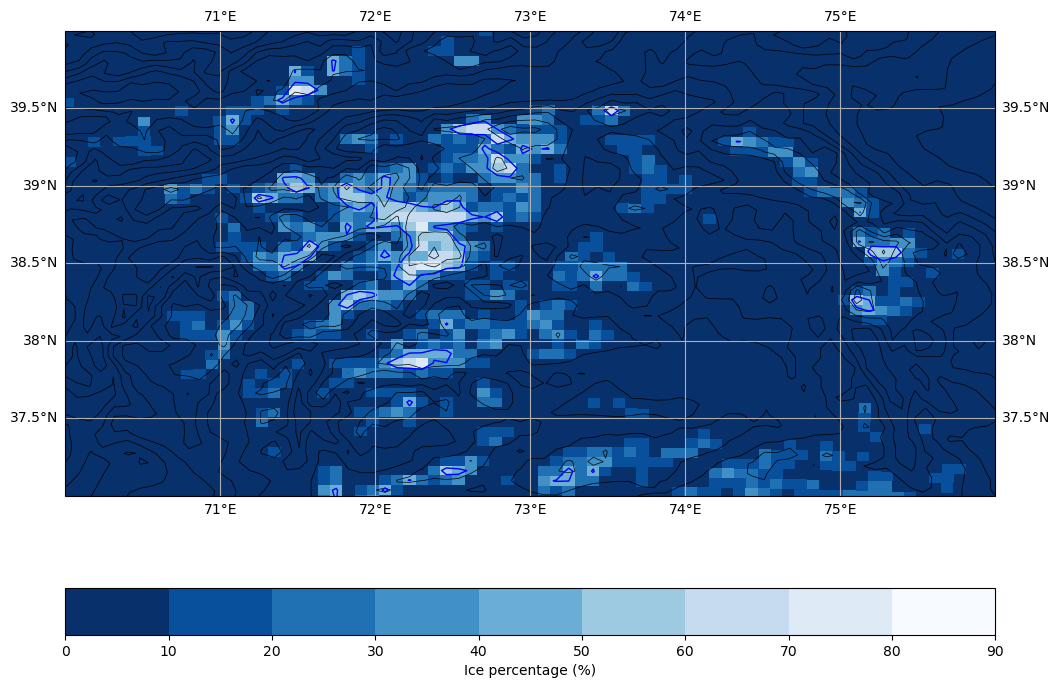

In [39]:
ice_level = 40 # Seuil à partir duquel on considère qu'on observe de la glace

clevs = np.arange(0, 100, 10) # Echelle de couleur de 0 à 100% tous les 10%
cmap = plt.get_cmap("Blues_r") # Palette de couleur bleu (reverse) pour voir le % de glace par grille
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N) 


fig, ax = plt.subplots(figsize=(12,12),subplot_kw={'projection': ccrs.PlateCarree()}) # Utilisation de la projection plate carré

#### Courbes de niveau (tous les 500m) ####
SH = ax.contour(ds_lon, ds_lat, ds_SH, 
           levels=[500,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000], # Affichage des lignes de topographie
           colors="k", linewidths=0.5,
           transform=ccrs.PlateCarree())
#ax.clabel(SH, SH.levels, inline=True, fontsize=6, fmt="%d", inline_spacing=1) # Affiche valeur sur les courbes

#### Countour glaciers ####
ax.contour(ds_lon, ds_lat, ds_ICE, 
           levels=[ice_level], # Défini les lignes de contour des glaciers (bleu) où la grille dépasse la valeur de ice_level 
           colors="b", linewidths=1,
           transform=ccrs.PlateCarree())

# #### Mera Peak coord ####
# ax.plot(merap_lon, merap_lat,  # Coord exact du Mera Peak
#         marker='o', markersize=10,
#         markeredgecolor='black', markerfacecolor='red',
#         transform=ccrs.PlateCarree())

#### Percentage of ice ####
im = ax.pcolormesh(ds_lon, ds_lat, ds_ICE,
                   cmap=cmap, norm=norm, # Affiche la couleur du % de glace
                   transform=ccrs.PlateCarree(),
                   shading="auto")
ax.set_extent([70, 76, 37, 40], crs=ccrs.PlateCarree()) # Défini les limites (lon, lat) du domaine observable 
#ax.set_extent([86.7, 87.1, 27.6, 27.9], crs=ccrs.PlateCarree()) # Défini les limites (lon, lat) du domaine observable zoom

ax.gridlines(draw_labels=True) # Grille de lattitude et longitude
plt.colorbar(im, orientation="horizontal", pad=0.1, label="Ice percentage (%)") # Paramètres de la barre d'altitude (disposition horizontale / taille / légende)
plt.show()

### SMB on sector 1

In [14]:
sector = 2

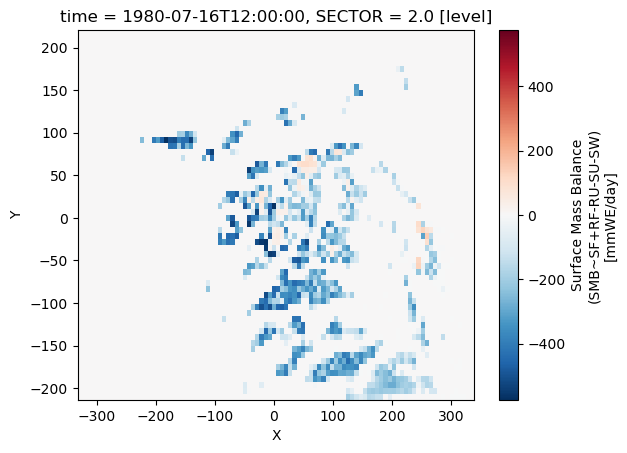

In [15]:
variable='SMB' 
#"Surface Mass Balance (SMB~SF+RF-RU-SU-SW)" 

fileNameF= variable+'_mon_MARv3.14_ER5_spin2_'+domain_2+'_1980-2024.nc'
ds_SMB= xr.open_dataset(sourceData_1+fileNameF).SMB.sel(SECTOR=sector).load()

ds_SMB = ds_SMB.assign_coords(X=np.round(ds_SMB.X.values))
ds_SMB = ds_SMB.assign_coords(Y=np.round(ds_SMB.Y.values))
ds_SMB = ds_SMB.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_SMB = ds_SMB[:,k:-k,k:-k]
ds_SMB.isel(time=6).plot()

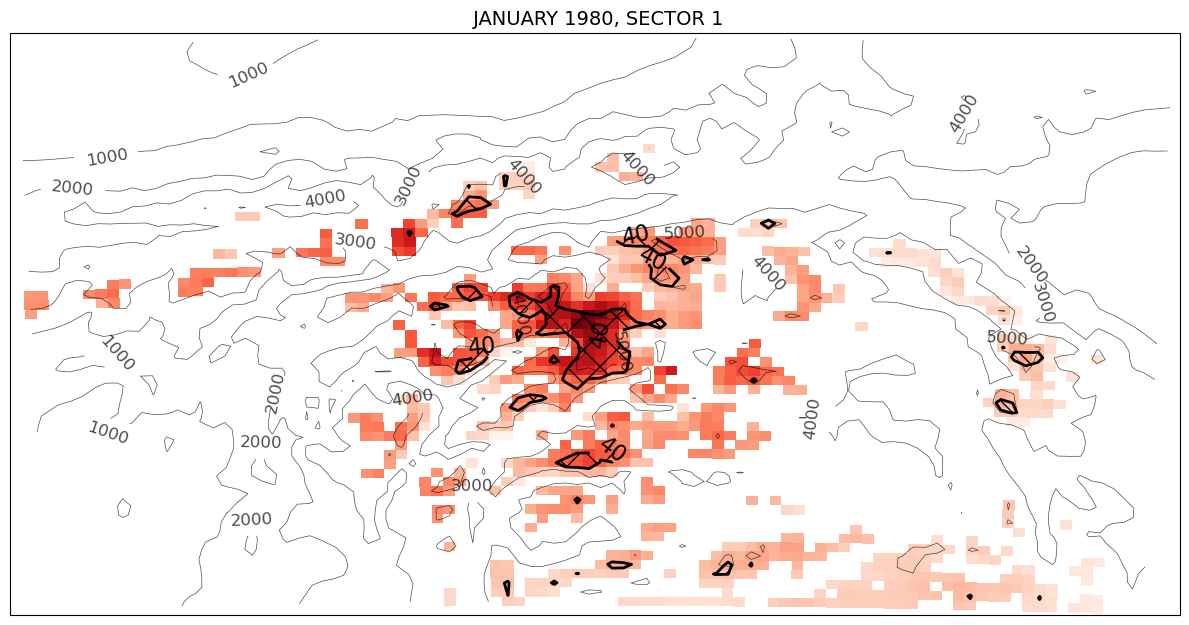

In [44]:
ice_level=40#

cmap_mod = plt.get_cmap('terrain')

fig, ax = plt.subplots(figsize=(12, 12), subplot_kw={'projection': ccrs.PlateCarree()})

smb_data = ds_SMB.isel(time=0)
smb_mask = np.ma.masked_where(smb_data == 0, smb_data)

smb = ax.pcolormesh(
    ds_lon, ds_lat, smb_mask,
    transform=ccrs.PlateCarree(),
    cmap="Reds",   # une seule couleur
    shading="auto")

ICE1=ax.contourf(ds_lon, ds_lat,ds_ICE,
            levels=[10,ice_level,100],
            hatches=['','X','X'],
            colors="none",
            transform=ccrs.PlateCarree())
ax.set_aspect(1.0)

SH1 = ax.contour(ds_lon, ds_lat, ds_SH,
                             levels=[1000,2000,3000,4000,5000,6000,7000],
                             colors="k", linewidths=0.5, alpha=0.7,
                             transform=ccrs.PlateCarree())
ax.clabel(SH1, inline=True, fontsize=12, fmt="%d")
    
ICE2= ax.contour(ds_lon, ds_lat, ds_ICE,
                    levels=[ice_level],
                    colors="black", linewidths=2.0, alpha=1.0,
                    transform=ccrs.PlateCarree())

ax.clabel(ICE2, inline=True, fontsize=16, fmt="%d")

fig.subplots_adjust(left=0.2, right=0.8, top=0.95, bottom=0.1, wspace=0.05, hspace=0.2)
plt.tight_layout()
ax.set_title(f" JANUARY 1980, SECTOR 1", fontsize=14)

plt.show()

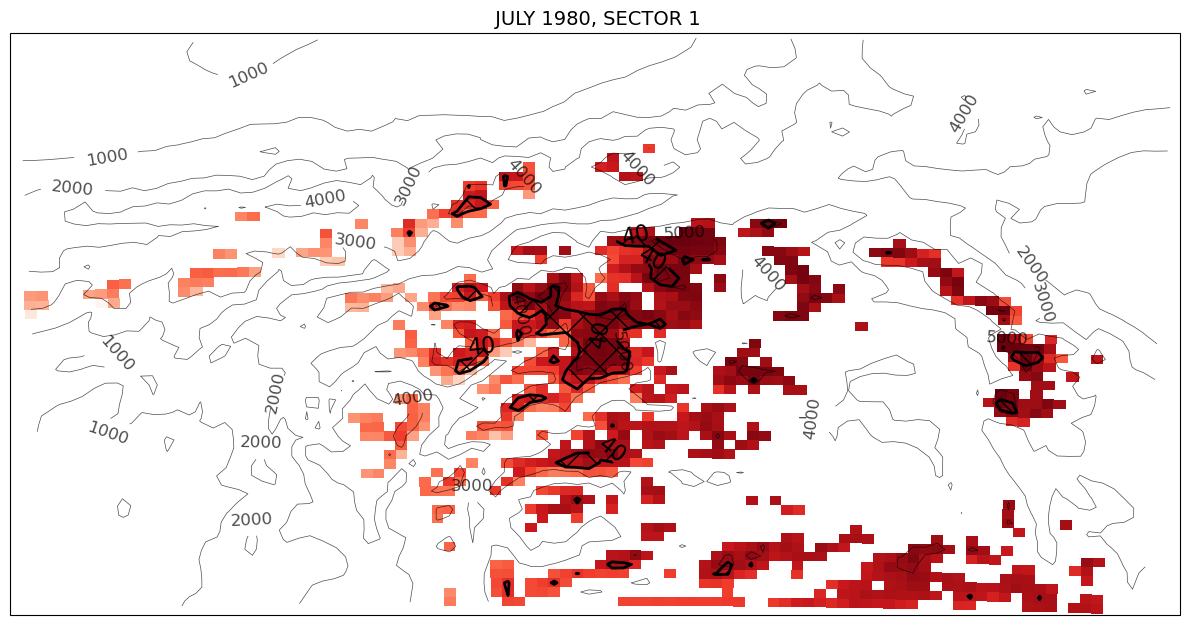

In [46]:
ice_level=40#

cmap_mod = plt.get_cmap('terrain')

fig, ax = plt.subplots(figsize=(12, 12), subplot_kw={'projection': ccrs.PlateCarree()})

smb_data = ds_SMB.isel(time=6)
smb_mask = np.ma.masked_where(smb_data == 0, smb_data)

smb = ax.pcolormesh(
    ds_lon, ds_lat, smb_mask,
    transform=ccrs.PlateCarree(),
    cmap="Reds",   # une seule couleur
    shading="auto")

ICE1=ax.contourf(ds_lon, ds_lat,ds_ICE,
            levels=[10,ice_level,100],
            hatches=['','X','X'],
            colors="none",
            transform=ccrs.PlateCarree())
ax.set_aspect(1.0)

SH1 = ax.contour(ds_lon, ds_lat, ds_SH,
                             levels=[1000,2000,3000,4000,5000,6000,7000],
                             colors="k", linewidths=0.5, alpha=0.7,
                             transform=ccrs.PlateCarree())
ax.clabel(SH1, inline=True, fontsize=12, fmt="%d")
    
ICE2= ax.contour(ds_lon, ds_lat, ds_ICE,
                    levels=[ice_level],
                    colors="black", linewidths=2.0, alpha=1.0,
                    transform=ccrs.PlateCarree())

ax.clabel(ICE2, inline=True, fontsize=16, fmt="%d")

fig.subplots_adjust(left=0.2, right=0.8, top=0.95, bottom=0.1, wspace=0.05, hspace=0.2)
plt.tight_layout()
ax.set_title(f" JULY 1980, SECTOR 1", fontsize=14)

plt.show()

### SMB on sector 1

In [73]:
sector = 2

In [78]:
variable='SMB' 
#"Surface Mass Balance (SMB~SF+RF-RU-SU-SW)" 

fileNameF= variable+'_mon_MARv3.14_ER5_spin2_'+domain_2+'_1980-2024.nc'
ds_SMB= xr.open_dataset(sourceData_1+fileNameF).SMB.sel(SECTOR=sector).load()

ds_SMB = ds_SMB.assign_coords(X=np.round(ds_SMB.X.values))
ds_SMB = ds_SMB.assign_coords(Y=np.round(ds_SMB.Y.values))
ds_SMB = ds_SMB.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_SMB = ds_SMB[:,k:-k,k:-k]

#JULY
# time_step = 6
# ds_SMB.isel(time=time_step).plot()

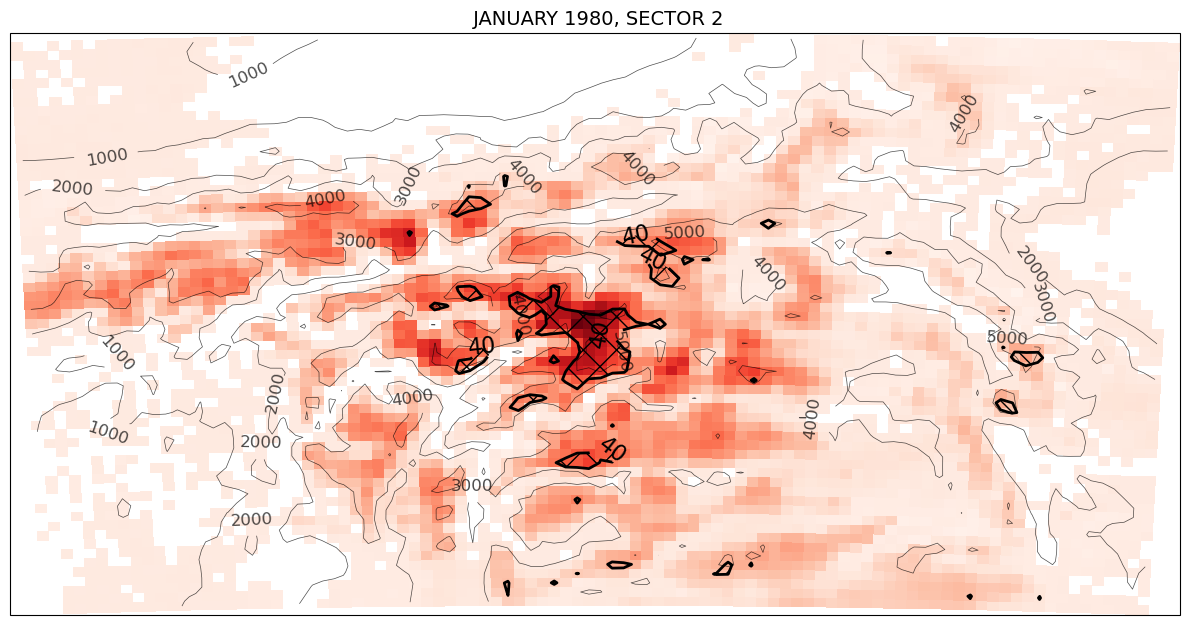

In [75]:
#JULY
time_step = 0

ice_level=40#

cmap_mod = plt.get_cmap('terrain')

fig, ax = plt.subplots(figsize=(12, 12), subplot_kw={'projection': ccrs.PlateCarree()})

smb_data = ds_SMB.isel(time=time_step)
smb_mask = np.ma.masked_where(smb_data == 0, smb_data)

smb = ax.pcolormesh(
    ds_lon, ds_lat, smb_mask,
    transform=ccrs.PlateCarree(),
    cmap="Reds",   # une seule couleur
    shading="auto")

ICE1=ax.contourf(ds_lon, ds_lat,ds_ICE,
            levels=[10,ice_level,100],
            hatches=['','X','X'],
            colors="none",
            transform=ccrs.PlateCarree())
ax.set_aspect(1.0)

SH1 = ax.contour(ds_lon, ds_lat, ds_SH,
                             levels=[1000,2000,3000,4000,5000,6000,7000],
                             colors="k", linewidths=0.5, alpha=0.7,
                             transform=ccrs.PlateCarree())
ax.clabel(SH1, inline=True, fontsize=12, fmt="%d")
    
ICE2= ax.contour(ds_lon, ds_lat, ds_ICE,
                    levels=[ice_level],
                    colors="black", linewidths=2.0, alpha=1.0,
                    transform=ccrs.PlateCarree())

ax.clabel(ICE2, inline=True, fontsize=16, fmt="%d")

fig.subplots_adjust(left=0.2, right=0.8, top=0.95, bottom=0.1, wspace=0.05, hspace=0.2)
plt.tight_layout()
ax.set_title(f" JANUARY 1980, SECTOR 2", fontsize=14)

plt.show()

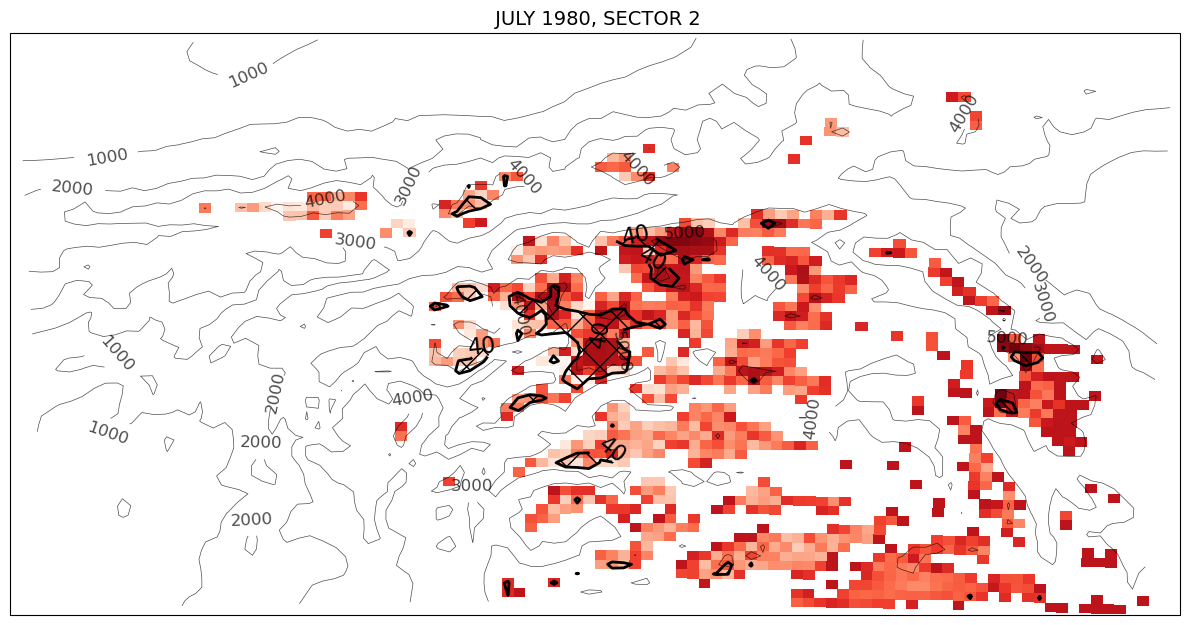

In [76]:
#JANUARY
time_step = 6

ice_level=40#

cmap_mod = plt.get_cmap('terrain')

fig, ax = plt.subplots(figsize=(12, 12), subplot_kw={'projection': ccrs.PlateCarree()})

smb_data = ds_SMB.isel(time=time_step)
smb_mask = np.ma.masked_where(smb_data == 0, smb_data)

smb = ax.pcolormesh(
    ds_lon, ds_lat, smb_mask,
    transform=ccrs.PlateCarree(),
    cmap="Reds",   # une seule couleur
    shading="auto")

ICE1=ax.contourf(ds_lon, ds_lat,ds_ICE,
            levels=[10,ice_level,100],
            hatches=['','X','X'],
            colors="none",
            transform=ccrs.PlateCarree())
ax.set_aspect(1.0)

SH1 = ax.contour(ds_lon, ds_lat, ds_SH,
                             levels=[1000,2000,3000,4000,5000,6000,7000],
                             colors="k", linewidths=0.5, alpha=0.7,
                             transform=ccrs.PlateCarree())
ax.clabel(SH1, inline=True, fontsize=12, fmt="%d")
    
ICE2= ax.contour(ds_lon, ds_lat, ds_ICE,
                    levels=[ice_level],
                    colors="black", linewidths=2.0, alpha=1.0,
                    transform=ccrs.PlateCarree())

ax.clabel(ICE2, inline=True, fontsize=16, fmt="%d")

fig.subplots_adjust(left=0.2, right=0.8, top=0.95, bottom=0.1, wspace=0.05, hspace=0.2)
plt.tight_layout()
ax.set_title(f" JULY 1980, SECTOR 2", fontsize=14)

plt.show()